In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import config
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.cleaning import clean
from src.feature_engineering import build_panel_data

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

#load data
df = pd.read_csv(config.DB_LOCATION)
cleaned, full_history = clean(df)
panel_data, last_complete_year = build_panel_data(cleaned, full_history)


test = panel_data[panel_data["Year"] == 2024]
test_X = test[config.FEATURES]
test_y = test["Churns"]

# generate calibrated probabilities on test set
calibrated_clf = joblib.load(Path().resolve() / "calibrated_model.pkl")
probs = calibrated_clf.predict_proba(test_X)[:, 1]

C:\Users\bnpar\AppData\Local\Temp\ipykernel_19880\4027525280.py:16: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config.DB_LOCATION)


### Decision Framework

For any individual lifter $i$, a retention intervention should be applied **if the expected value of intervening exceeds the expected value of leaving them alone.**

The expected profit generated by a single lifter with no intervention is:
$$E_{\text{no int}} = (1 - p_i) \cdot V$$

And with intervention:
$$E_{\text{int}} = P_i(\text{stay} \mid \text{intervention}) \cdot (V - C)$$

Where:
- $V$ is the membership value of a retained lifter.
- $C$ is the net operational cost of running a half price coaching session.
- $p_i$ is the predicted baseline churn probability for lifter $i$.
- $P_i(\text{stay} \mid \text{intervention})$ is the probability individual lifter $i$ is retained given the incentive.

An intervention should be offered to a lifter when $E_{\text{int}} > E_{\text{no int}}$. This is equivalent to
$$p_i > 1 - \frac{P_i(\text{stay} \mid \text{intervention}) \cdot (V - C)}{V}$$

Obtaining an estimate of $P_i(\text{stay} \mid \text{intervention})$ for each individual lifter **would require uplift modelling**. Without an individual uplift model, we **assume a constant $P_i(\text{stay} \mid \text{intervention})$** for the targeted cohort to calculate a threshold $t^*$, above which lifters should be offered a retention intervention.
$$t^* = 1 - \frac{\bar{P}(\text{stay} \mid \text{intervention}) \cdot (V - C)}{V}$$


Note that the value of $t^*$ depends on $P(\text{stay} \mid \text{intervention})$. But $P(\text{stay} \mid \text{intervention})$ is the probability for lifters above the threshold $t^*$, so $t^*$ must be known to estimate $P(\text{stay} \mid \text{intervention})$. There is circularity there. Therefore an **iterative approach**, where the threshold $t^*$ and the estimated value of $P(\text{stay} \mid \text{intervention})$ is refined annually, is outlined below:

$\bar{P}(\text{stay} \mid \text{intervention})$ is initially estimated. This is used to calculate an initial estimate of $t^*$. Then when the interventions are offered annually, a portion of lifters with $p_i>t^*$ are not offered interventions and act as a **control group for an A/B test**. This can then be used to obtain a new estimate of $P(\text{stay} \mid \text{intervention})$ which is then used to update $t^*$ for the following year. $t^*$ is expected to stabilise over successive iterations. However, this depends on the sensitivity of $P(\text{stay} \mid \text{intervention})$ to the exact threshold $t^*$ and should be monitored over time. The iterative approach can be expressed:

$$t^*_n = 1 - \frac{\bar{P}_{n-1}(\text{stay} \mid \text{intervention}) \cdot (V - C)}{V}$$

where $n$ corresponds to the year. 

### Notes on constant assumption and enforcing upper threshold
Assuming $P(\text{stay} \mid \text{intervention})$ is constant in the group targeted for intervention retentions means the optimisation logic can only establish a lower operational threshold ($t^*$). It cannot enforce an upper risk threshold (a probability boundary above which a member is unlikely to be retained regardless of intervention). To solve this, a **pragmatic upper threshold** ($t^*_{upper}$) is enforced (e.g. $p_i = 0.85$) above which retention interventions are not offered.

### A/B test using control group

The cell below shows that to have statistical power of 80% and minimum detectable effect of 5%, a significant portion of lifters in target group need to be held out as control group for A/B test. The control group must come from lifters in the targeted band ($t^*<p_i< t^*_{upper}$)

In [3]:
# Calculate the optimal threshold algebraically
V = 50                  # financial value of a retained lifter
C = 10                  # cost of rentention intervention
t_star = 1 - (p_retention * (V - C) / V)
t_star = round(t_star, 2)

In [4]:
UPPER_THRESHOLD = 0.85
p_retention = 0.35      
in_window = (probs > t_star) & (probs < UPPER_THRESHOLD)


baseline_churn = test_y.reset_index(drop=True)[in_window].mean()
mde = 0.05 
alpha = 0.05
power = 0.8
effect = proportion_effectsize(baseline_churn - mde, baseline_churn)
n_per_group = NormalIndPower().solve_power(effect_size=effect, alpha=alpha, power=power)
n_per_group = float(n_per_group[0]) if hasattr(n_per_group, '__len__') else float(n_per_group)

actual_n = int(((probs > t_star) & (probs < UPPER_THRESHOLD)).sum())
print(f'Baseline churn rate above t*: {baseline_churn:.1%}')
print(f'Required control group size: {round(n_per_group):,}')
print(f'Available in intervention band: {actual_n:,}')
print(f'Required control group as % of targeted lifters: {round(n_per_group) / actual_n:.1%}')

Baseline churn rate above t*: 75.2%
Required control group size: 1,245
Available in intervention band: 5,793
Required control group as % of targeted lifters: 21.5%


### Expected profit

In [15]:
n_intervene = in_window.sum()
n_control = round(n_per_group)
n_treatment = n_intervene - n_control

#p_retention refers to probability of stay given retention interventiom+n
profit_intervened = p_retention * n_treatment * (V - C) # expected profit contribution from people in intervention band

#expected profit contribution from people in control group
rng = np.random.default_rng(42)
control_indices = rng.choice(np.where(in_window)[0], size=n_control, replace=False)
profit_control = np.sum((1 - probs[control_indices]) * V)  

#expected profit from people outside intervention band
profit_not_intervened = np.sum((1 - probs[~in_window]) * V)
total_expected_profit = profit_intervened + profit_control + profit_not_intervened
baseline_no_intervention = np.sum((1 - probs) * V)

print(f'Expected profit with interventions: £{total_expected_profit:,.0f}')
print(f'Expected profit with no interventions: £{baseline_no_intervention:,.0f}')
print(f'Expected profit uplift from baseline: £{total_expected_profit - baseline_no_intervention:,.0f}')

Expected profit with interventions: £1,007,632
Expected profit with no interventions: £997,869
Expected profit uplift from baseline: £9,763


### Profit sensitivity to assumptions/estimations

The section above acknowledges that at best we can use an estimate of the average $P(\text{stay} \mid \text{intervention})$ for the targeted cohort. It is therefore worth exploring the **sensitivity of profit to the estimation** of $P(\text{stay} \mid \text{intervention})$. If we use $\bar{P}_{0}(\text{stay} \mid \text{intervention})$ = 0.35, we find  $t^*_1$ = 0.72. Therefore in the plot below, we fix $t^*$ and explore what profit would be for different percentage uptake of retention interventions.

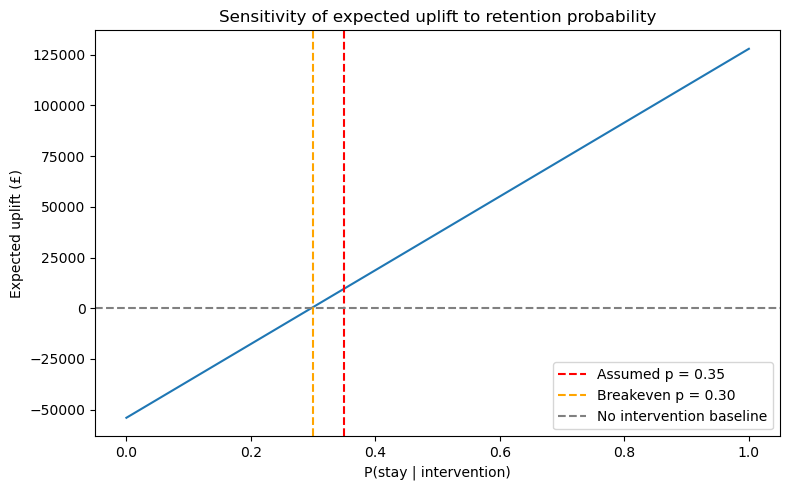

In [14]:
p_retentions = np.arange(0, 1.01, 0.01)
uplifts = []

for p in p_retentions:
    profit = p * n_treatment * (V - C) + profit_control + profit_not_intervened
    uplifts.append(profit - baseline_no_intervention)

uplifts = np.array(uplifts)
breakeven = p_retentions[np.argmax(uplifts >= 0)]

plt.figure(figsize=(8, 5))
plt.plot(p_retentions, uplifts)
plt.axvline(x=p_retention, color='red', linestyle='--', label=f'Assumed p = {p_retention}')
plt.axvline(x=breakeven, color='orange', linestyle='--', label=f'Breakeven p = {breakeven:.2f}')
plt.axhline(y=0, color='grey', linestyle='--', label='No intervention baseline')
plt.xlabel('P(stay | intervention)')
plt.ylabel('Expected uplift (£)')
plt.title('Sensitivity of expected uplift to retention probability')
plt.legend()
plt.tight_layout()
plt.show()

### Limitations & Future Framework Considerations

* **Static Assumption Constraint:** Utilizing a static, flat retention scalar ($P(\text{stay} \mid \text{intervention}) = 0.35$) serves as an excellent operational MVP for Year 1. However, it forces the model to assume that a coaching session is equally effective for a highly loyal member as it is for a member on the verge of quitting.
* **Absence of an Upper Risk Ceiling:** Because a uniform baseline value is applied evenly across the spectrum, the optimization logic can only establish a lower operational threshold ($t^*$). It cannot mathematically isolate or enforce an upper risk threshold (a probability boundary above which a member is effectively a 'lost cause' and intervening represents a guaranteed financial loss).
* **Path Forward:** Transitioning to the continuous logistic interaction framework in the next iteration resolves both limitations by calculating custom survival probabilities unique to each individual's baseline risk score, introducing natural lower and upper boundaries to protect business margins.